In [39]:
import joblib
from Softwareprojekt import X_test, y_test, plot_heat, numeric_features, categorical_features

# Gegenüberstellung der Modelle und Performance

## Logistische Regression als Baseline 

In [40]:
# Modell
logistic_regression = joblib.load("logistic_regression_model.pkl")

In [41]:
# Feature Importance
importances = logistic_regression.named_steps['classifier'].coef_[0]
feature_names = numeric_features.tolist() + categorical_features.tolist()
importance_report = sorted(zip(importances, feature_names), reverse=True)

print("\nFeature Importances:")
for importance, feature in importance_report:
    print(f"{feature}: {importance:.4f}")


Feature Importances:
OPTIME: 0.3057
ANESTHES: 0.1852
SURGSPEC: 0.1154
WNDINF: 0.1107
DIABETES: 0.0841
INOUT: 0.0803
AGE: 0.0721
SMOKE: 0.0518
WTLOSS: 0.0489
DYSPNEA: 0.0339
TRANSFUS: 0.0307
STEROID: 0.0289
ASCITES: 0.0241
HXCOPD: 0.0226
SEX: 0.0201
RENAFAIL: 0.0184
HXCHF: 0.0108
BLEEDIS: 0.0075
Year: 0.0037
WEIGHT: 0.0000
FNSTATUS2: 0.0000
DIALYSIS: -0.0007
VENTILAT: -0.0072
BMI: -0.0094
PRSEPIS: -0.0111
HEIGHT: -0.0349
HYPERMED: -0.0487
RACE_NEW: -0.0858
DISCANCR: -0.8785


Genauigkeit: 0.6492
F-1 Score für 1-Class: 0.1302
              precision    recall  f1-score   support

           0       0.98      0.65      0.78     35202
           1       0.07      0.68      0.13      1409

    accuracy                           0.65     36611
   macro avg       0.53      0.66      0.46     36611
weighted avg       0.95      0.65      0.76     36611



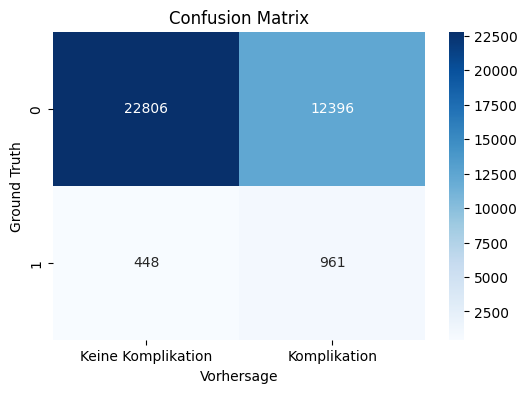

In [42]:
# Visualisierung der Performance
y_pred_test = logistic_regression.predict(X_test)
plot_heat(y_test, y_pred_test)

## XGBoost Classifier

In [43]:
xgb = joblib.load('XGB.pkl')

In [44]:
# Feature Importance
importances = xgb.named_steps['classifier'].feature_importances_
feature_names = numeric_features.tolist() + categorical_features.tolist()
importance_report = sorted(zip(importances, feature_names), reverse=True)

print("\nFeature Importances:")
for importance, feature in importance_report:
    if importance > 0:
        print(f"{feature}: {importance:.4f}")


Feature Importances:
ANESTHES: 0.0288
Year: 0.0159
HEIGHT: 0.0112
SURGSPEC: 0.0105
OPTIME: 0.0099
PRSEPIS: 0.0078
FNSTATUS2: 0.0074
WTLOSS: 0.0043
ASCITES: 0.0041
INOUT: 0.0038
DYSPNEA: 0.0036
HYPERMED: 0.0036
HXCHF: 0.0036
WNDINF: 0.0035
RACE_NEW: 0.0033
DIABETES: 0.0033
SMOKE: 0.0031
SEX: 0.0031
HXCOPD: 0.0029
AGE: 0.0029
TRANSFUS: 0.0027
RENAFAIL: 0.0026
BLEEDIS: 0.0025
DIALYSIS: 0.0023
WEIGHT: 0.0023
VENTILAT: 0.0021
BMI: 0.0019
STEROID: 0.0016


Genauigkeit: 0.8457
F-1 Score für 1-Class: 0.1535
              precision    recall  f1-score   support

           0       0.97      0.87      0.92     35202
           1       0.10      0.36      0.15      1409

    accuracy                           0.85     36611
   macro avg       0.53      0.61      0.53     36611
weighted avg       0.94      0.85      0.89     36611



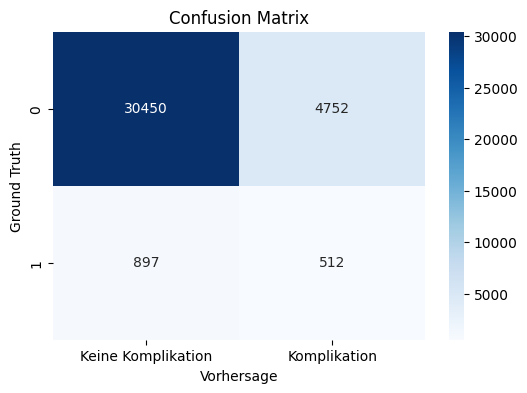

In [45]:
y_pred_test = xgb.predict(X_test)

plot_heat(y_test, y_pred_test)

## Random Forest Classifier

In [46]:
random_forest = joblib.load('random_forest_model.pkl')

In [47]:
# Feature Importance
importances = xgb.named_steps['classifier'].feature_importances_
feature_names = numeric_features.tolist() + categorical_features.tolist()
importance_report = sorted(zip(importances, feature_names), reverse=True)

print("\nFeature Importances:")
for importance, feature in importance_report:
    if importance > 0:
        print(f"{feature}: {importance:.4f}")


Feature Importances:
ANESTHES: 0.0288
Year: 0.0159
HEIGHT: 0.0112
SURGSPEC: 0.0105
OPTIME: 0.0099
PRSEPIS: 0.0078
FNSTATUS2: 0.0074
WTLOSS: 0.0043
ASCITES: 0.0041
INOUT: 0.0038
DYSPNEA: 0.0036
HYPERMED: 0.0036
HXCHF: 0.0036
WNDINF: 0.0035
RACE_NEW: 0.0033
DIABETES: 0.0033
SMOKE: 0.0031
SEX: 0.0031
HXCOPD: 0.0029
AGE: 0.0029
TRANSFUS: 0.0027
RENAFAIL: 0.0026
BLEEDIS: 0.0025
DIALYSIS: 0.0023
WEIGHT: 0.0023
VENTILAT: 0.0021
BMI: 0.0019
STEROID: 0.0016


Genauigkeit: 0.8892
F-1 Score für 1-Class: 0.1155
              precision    recall  f1-score   support

           0       0.97      0.92      0.94     35202
           1       0.08      0.19      0.12      1409

    accuracy                           0.89     36611
   macro avg       0.52      0.55      0.53     36611
weighted avg       0.93      0.89      0.91     36611



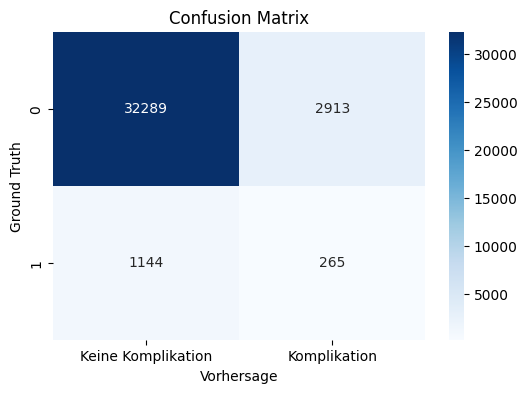

In [48]:
# Visualisierung der Performance
y_pred_test = random_forest.predict(X_test)
plot_heat(y_test, y_pred_test)

## Neuronales Netz

In [49]:
%%capture
import torch
import torch.nn as nn
import numpy as np
from Softwareprojekt import y_test, plot_heat
from sklearn.metrics import f1_score, classification_report, roc_auc_score, precision_recall_curve
from network import X_test, X_train, BinaryClassifier


best_params = torch.load("best_model_params.pth")

model = BinaryClassifier(
    input_size=X_train.shape[1],
    hidden_sizes=[best_params[f"hidden_size_{i}"] for i in range(best_params["num_layers"])],
    activation_fns=[best_params[f"activation_{i}"] for i in range(best_params["num_layers"])],
    dropout_rate=best_params["dropout_rate"]
)

model.load_state_dict(torch.load("best_neural_net.pth"))
model.eval()

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

with torch.no_grad():
    outputs = model(X_test_tensor)
    y_scores = torch.sigmoid(outputs).squeeze().numpy()  # Apply sigmoid for probabilities

    # Threshold angepasst wie in network.py
    precision, recall, thresholds = precision_recall_curve(y_test, y_scores)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
    best_threshold = thresholds[np.argmax(f1_scores)]

    y_pred_binary = (y_scores > best_threshold).astype(int)

Genauigkeit: 0.9125
F-1 Score für 1-Class: 0.1767
              precision    recall  f1-score   support

           0       0.97      0.94      0.95     35202
           1       0.14      0.24      0.18      1409

    accuracy                           0.91     36611
   macro avg       0.55      0.59      0.57     36611
weighted avg       0.94      0.91      0.92     36611



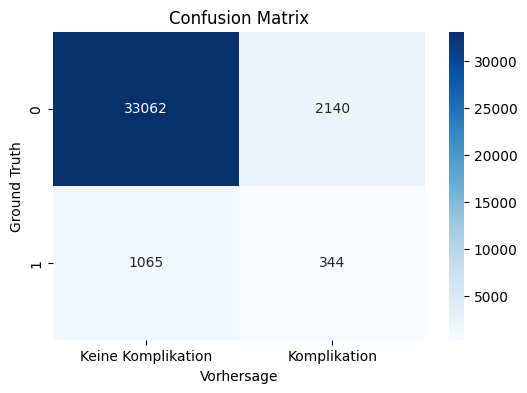

In [50]:
plot_heat(y_test, y_pred_binary)